M9-S2: Fairness and Bias Analysis
The purpose of this assignment is to analyze fairness issues in machine learning systems and investigate demographic disparities in the Adult Census Income dataset.

Exercise 1: Conceptual Questions

1. Types of Bias

The camera system demonstrates representation bias because the training dataset mainly contains images of popular influencers and may not adequately represent people with different skin tones. As a result, the model performs better for light-skinned users.

Another issue is measurement bias. The image enhancement process was likely optimized according to visual characteristics common in the training data. When applied to dark-skinned users, the same adjustments produce unnatural results, reducing image quality.

2. Fairness Metrics in Practice

Equal Opportunity is more appropriate in this scenario. The city wants neighborhoods with similar actual fire risk to receive similar treatment regardless of demographic characteristics. Equal Opportunity focuses on providing equal outcomes for individuals or groups that truly belong to the positive class, which aligns with the goal of fair resource allocation.

3. The Limits of Mitigation

Even after removing the gender column, other variables may indirectly reveal gender information. Examples include employment history, career breaks, educational background, job titles, previous industries, part-time work experience, and membership in certain organizations. These variables can act as proxy features and allow the model to continue learning gender-related patterns.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("adult.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
#Dataset Overview

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (32561, 15)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']

First 5 rows:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
#Overall Percentage of Individuals with Income >50K

high_income_rate = (df["income"] == ">50K").mean() * 100
print(f"Overall percentage earning >50K: {high_income_rate:.2f}%")

Overall percentage earning >50K: 24.08%


In [6]:
#Gender-Based Analysis

gender_income = (
    df.groupby("sex")["income"]
      .apply(lambda x: (x == ">50K").mean() * 100)
      .reset_index(name="High Income Percentage")
)

gender_income

,sex,High Income Percentage
0,Female,10.946059
1,Male,30.573658


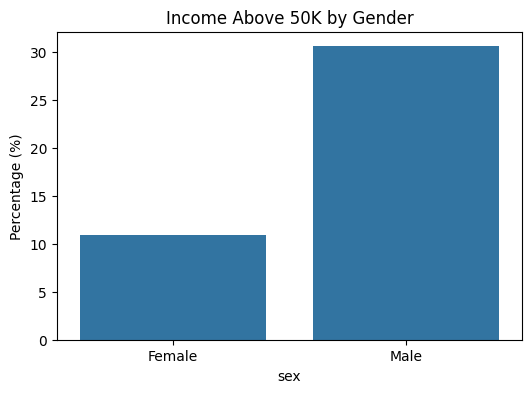

In [7]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=gender_income,
    x="sex",
    y="High Income Percentage"
)

plt.title("Income Above 50K by Gender")
plt.ylabel("Percentage (%)")
plt.show()

In [8]:
#Race-Based Analysis   

race_income = (
    df.groupby("race")["income"]
      .apply(lambda x: (x == ">50K").mean() * 100)
      .reset_index(name="High Income Percentage")
)

race_income

,race,High Income Percentage
0,Amer-Indian-Eskimo,11.575563
1,Asian-Pac-Islander,26.564004
2,Black,12.387964
3,Other,9.225092
4,White,25.585994


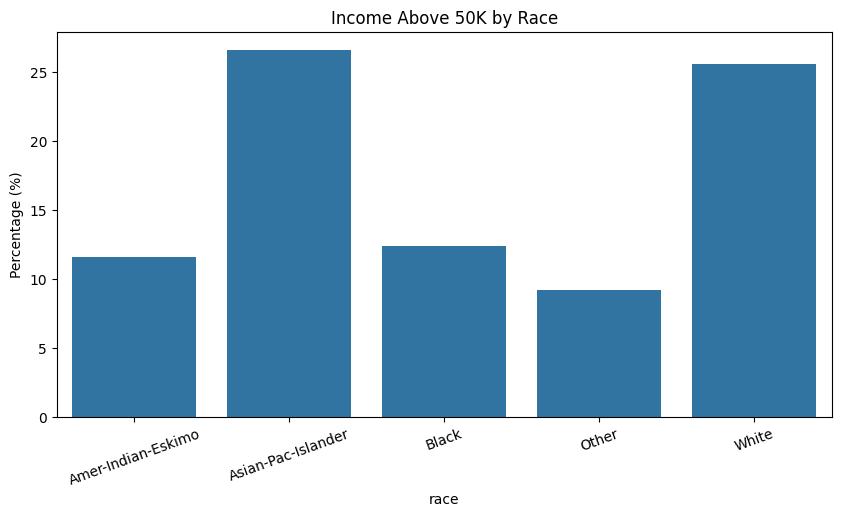

In [9]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=race_income,
    x="race",
    y="High Income Percentage"
)

plt.xticks(rotation=20)
plt.title("Income Above 50K by Race")
plt.ylabel("Percentage (%)")
plt.show()

The analysis reveals noticeable differences in income distribution across demographic groups. The percentage of individuals earning more than $50K varies substantially between genders and also differs across racial categories.

These disparities suggest that the dataset contains historical and social patterns that may be learned by machine learning models. If a predictive model is trained directly on this data without fairness mitigation techniques, it may reproduce or even amplify existing inequalities. Therefore, fairness auditing should be considered an essential step before deploying such systems in real-world applications.

Exercise 3: The Paradox of Fairness

The decision to enforce perfect Demographic Parity may create several unintended consequences. While equal approval rates appear fair at first glance, they do not necessarily reflect differences in financial risk among applicants.

If Group A historically has a lower default rate than Group B, forcing both groups to receive the same approval rate may increase the number of risky loans issued by the bank. This could lead to higher default rates, financial losses, and increased operational costs. In the long term, reduced profitability may affect the bank's ability to provide competitive services to all customers.

The policy may also create concerns regarding Equal Opportunity. Applicants who are highly qualified in one group could be rejected simply to maintain equal approval statistics. At the same time, less qualified applicants from another group could be approved to satisfy demographic targets. As a result, some individuals may be treated unfairly despite having stronger financial profiles.

This example demonstrates that fairness metrics can conflict with one another. Improving Demographic Parity does not automatically guarantee Equal Opportunity, predictive accuracy, or economic efficiency. Different fairness objectives often require difficult trade-offs.

The role of a data scientist is to measure these trade-offs, evaluate the consequences of different fairness interventions, and communicate the results clearly. However, deciding which fairness objective should take priority is ultimately a policy and business decision. These choices involve ethical, legal, and social considerations that go beyond technical optimization.

Therefore, fairness should not be viewed as a purely mathematical problem. Effective decision-making requires collaboration between data scientists, business leaders, regulators, and other stakeholders to determine which outcomes best align with organizational goals and societal values.